# PayPulse — Phase 4: Python Analytics

**Data cleaning · Exploratory Data Analysis · Feature Engineering**

This notebook takes the raw generated CSVs and (1) audits data quality,
(2) demonstrates a cleaning toolkit, (3) engineers modelling features, and
(4) explores the business through visual EDA. It reuses the importable pipeline
in `src/features.py` so the logic is shared with the Phase 5 notebook.


In [1]:

import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
here = Path.cwd()
ROOT = here.parent if here.name == 'notebooks' else here
sys.path.insert(0, str(ROOT / 'src'))
import config as cfg
import features as F

%matplotlib inline
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.titlesize'] = 12
cfg.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
print('libraries loaded  |  figures ->', cfg.FIGURES_DIR)


libraries loaded  |  figures -> C:\Users\abhi1\Desktop\filflo-tally-recon\paypulse\reports\figures


## 1. Load the raw data layer

In [2]:

raw = F.load_raw()
for name, df in raw.items():
    print(f'{name:13} {df.shape[0]:>7,} rows x {df.shape[1]} cols')
raw['transactions'].head()


transactions  250,001 rows x 10 cols
customers       8,000 rows x 9 cols
merchants       1,200 rows x 7 cols
banks              15 rows x 5 cols
devices         8,000 rows x 4 cols
campaigns          10 rows x 7 cols
cashback        4,103 rows x 5 cols


,transaction_id,customer_id,merchant_id,bank_id,device_id,amount,status,failure_reason,payment_mode,txn_timestamp
0,TXN00000001,CUST00198,MER00308,BNK02,DEV000198,506.15,SUCCESS,NaN,QR Code,2023-01-30 17:40:42
1,TXN00000002,CUST06463,MER00422,BNK01,DEV006463,"1,438.57",SUCCESS,NaN,UPI Lite,2023-01-16 16:04:01
2,TXN00000003,CUST03182,MER00877,BNK15,DEV003182,584.02,SUCCESS,NaN,QR Code,2023-01-24 14:43:06
3,TXN00000004,CUST01730,MER00308,BNK06,DEV001730,406.29,SUCCESS,NaN,QR Code,2023-01-14 20:27:30
4,TXN00000005,CUST04216,MER00781,BNK13,DEV004216,"2,205.01",SUCCESS,NaN,Collect Request,2023-01-23 14:40:14


## 2. Data-quality audit

We check the transactions table for the classic issues: duplicates, missing
values, non-positive amounts, invalid timestamps, unknown statuses, and logical
violations (a failure reason present on a non-failed row, or missing on a failed
row).

In [3]:

audit = F.data_quality_report(raw['transactions'])
display(audit)
issues = audit[(audit.check != 'rows') & (audit.value > 0)]
print('Issues requiring cleaning:', len(issues), '-> the generated data is clean.')


,check,value
0,rows,250001
1,duplicate_txn_ids,0
2,full_duplicate_rows,0
3,missing_customer_id,0
4,missing_amount,0
5,non_positive_amount,0
6,invalid_timestamps,0
7,invalid_status,0
8,reason_without_failure,0
9,failure_without_reason,0


Issues requiring cleaning: 0 -> the generated data is clean.


### 2b. Cleaning toolkit (demonstrated on a perturbed sample)

Because the generated data is already clean, we inject typical real-world defects
into a small sample and show `clean_transactions()` detecting and fixing them —
the technique you would apply to genuinely messy source data.

In [4]:

sample = raw['transactions'].head(1000).copy()
messy = sample.copy()
messy.loc[messy.index[:5],   'amount']        = -1              # invalid amounts
messy.loc[messy.index[5:8],  'txn_timestamp'] = 'not-a-date'   # broken timestamps
messy.loc[messy.index[8:10], 'status']        = 'succes'       # misspelled status
messy.loc[messy.index[10:15],'amount']        = np.nan         # missing amounts
messy = pd.concat([messy, messy.iloc[:7]], ignore_index=True)  # duplicate rows

print('Injected messy sample:', len(messy), 'rows')
display(F.data_quality_report(messy)[lambda d: d.value > 0])

clean, actions = F.clean_transactions(messy)
print('Cleaning actions:', actions)
remaining = int(F.data_quality_report(clean).query("check != 'rows'").value.sum())
print('Clean rows:', len(clean), '| remaining issues:', remaining)


Injected messy sample: 1007 rows


,check,value
0,rows,1007
1,duplicate_txn_ids,7
2,full_duplicate_rows,7
4,missing_amount,5
5,non_positive_amount,10
6,invalid_timestamps,5
7,invalid_status,2


Cleaning actions: {'dropped_duplicate_ids': 7, 'dropped_bad_timestamps': 3, 'dropped_bad_amounts': 10, 'dropped_bad_status': 2}
Clean rows: 985 | remaining issues: 0


## 3. Build the analysis frame & engineer features

We join transactions to every dimension, then derive the features the project
brief calls for: transaction hour, day-of-week, month, weekend flag, high-value
flag, ticket band, daypart, and per-transaction revenue.

In [5]:

txn  = F.engineer_transaction_features(F.build_analysis_frame(raw))
cust = F.engineer_customer_features(txn, raw['customers'])
txn['success_amount'] = txn['amount'] * txn['is_success']   # helper for GPV sums

print('transaction features:', txn.shape)
print('customer features   :', cust.shape)
txn[['transaction_id','amount','txn_hour','txn_day_name','is_weekend',
     'high_value_flag','ticket_band','daypart','revenue','merchant_category']].head()


transaction features: (250001, 40)
customer features   : (7747, 21)


,transaction_id,amount,txn_hour,txn_day_name,is_weekend,high_value_flag,ticket_band,daypart,revenue,merchant_category
0,TXN00000001,506.15,17,Monday,0,0,500-1k,Evening,10.12,Food Delivery
1,TXN00000002,"1,438.57",16,Monday,0,0,1k-3k,Afternoon,21.58,E-commerce
2,TXN00000003,584.02,14,Tuesday,0,0,500-1k,Afternoon,14.60,Entertainment
3,TXN00000004,406.29,20,Saturday,1,0,200-500,Evening,8.13,Food Delivery
4,TXN00000005,"2,205.01",14,Monday,0,0,1k-3k,Afternoon,11.03,Fuel


In [6]:

print('Customer-level engineered features:')
cust[['customer_id','n_txns','lifetime_spend','avg_ticket','success_rate',
      'high_value_share','recency_days','tenure_days','is_inactive']].head()


Customer-level engineered features:


,customer_id,n_txns,lifetime_spend,avg_ticket,success_rate,high_value_share,recency_days,tenure_days,is_inactive
0,CUST00001,44,"36,562.94",962.18,0.86,0.09,10,373,0
1,CUST00002,6,"6,168.77","1,233.75",0.83,0.17,56,710,0
2,CUST00003,3,"1,119.05",373.02,1.00,0.00,26,41,0
3,CUST00004,28,"49,431.82","1,901.22",0.93,0.14,14,895,0
4,CUST00005,13,"7,765.15",647.10,0.92,0.00,214,494,1


## 4. EDA — transaction amount distribution

count   250,001.00
mean      1,449.06
std       2,152.34
min          19.87
25%         383.02
50%         742.63
75%       1,598.56
max      58,912.32
Name: amount, dtype: float64


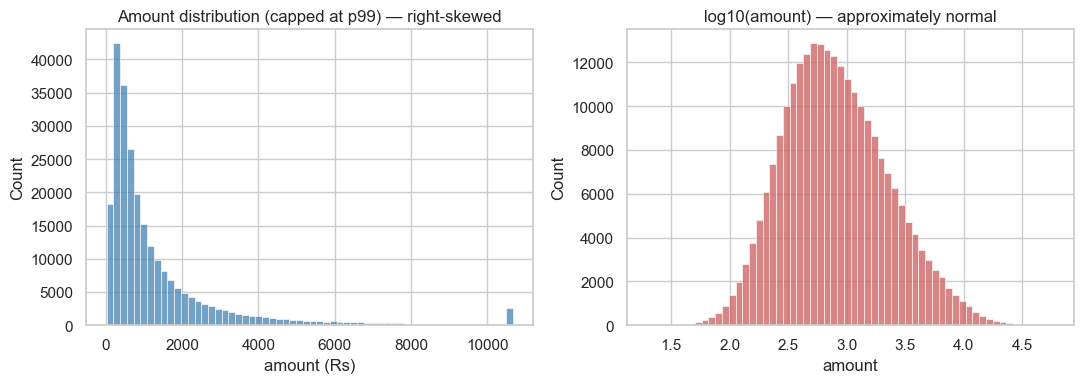

In [7]:

print(txn['amount'].describe().round(2))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(txn['amount'].clip(upper=txn['amount'].quantile(0.99)),
             bins=60, ax=ax[0], color='steelblue')
ax[0].set_title('Amount distribution (capped at p99) — right-skewed')
ax[0].set_xlabel('amount (Rs)')
sns.histplot(np.log10(txn['amount']), bins=60, ax=ax[1], color='indianred')
ax[1].set_title('log10(amount) — approximately normal')
plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / 'p4_amount_distribution.png', dpi=110)
plt.show()


## 5. Transaction status split

status
SUCCESS    86.83 %
FAILED      11.6 %
PENDING     1.58 %
Name: count, dtype: str


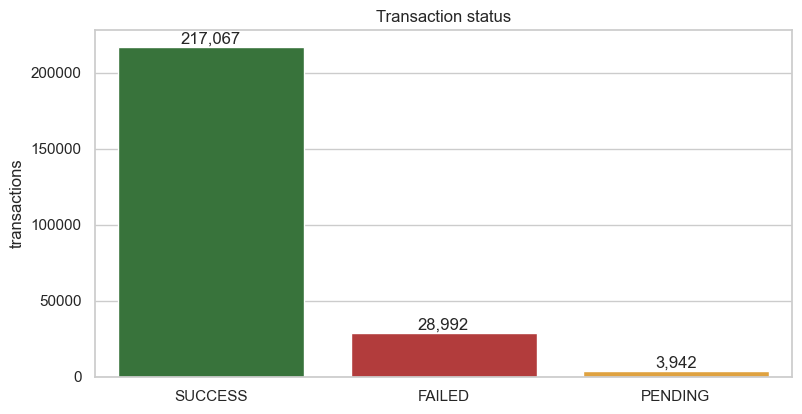

In [8]:

order  = ['SUCCESS', 'FAILED', 'PENDING']
colors = {'SUCCESS': '#2e7d32', 'FAILED': '#c62828', 'PENDING': '#f9a825'}
ct = txn['status'].value_counts()
print((ct / len(txn) * 100).round(2).astype(str) + ' %')
ax = sns.barplot(x=order, y=[ct[o] for o in order], palette=[colors[o] for o in order])
ax.set_title('Transaction status'); ax.set_ylabel('transactions')
for i, o in enumerate(order):
    ax.text(i, ct[o], f'{ct[o]:,}', ha='center', va='bottom')
plt.savefig(cfg.FIGURES_DIR / 'p4_status.png', dpi=110)
plt.show()


## 6. Temporal trends — growth, peak hours, weekday pattern

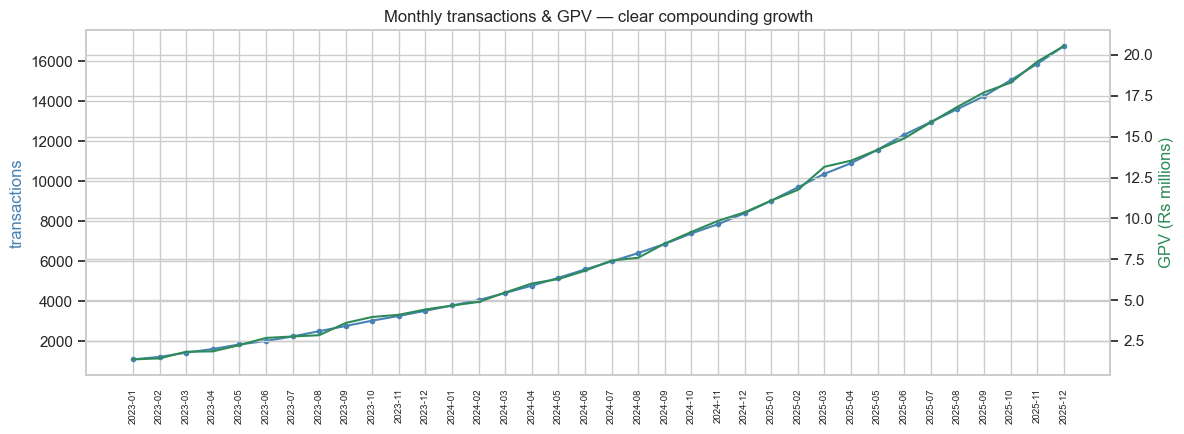

In [9]:

monthly = (txn.groupby('txn_year_month')
              .agg(txns=('transaction_id', 'size'),
                   gpv=('success_amount', 'sum'),
                   sr=('is_success', 'mean'))
              .reset_index())
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(monthly.txn_year_month, monthly.txns, marker='o', ms=3, color='steelblue')
ax1.set_ylabel('transactions', color='steelblue')
ax1.tick_params(axis='x', rotation=90, labelsize=7)
ax2 = ax1.twinx()
ax2.plot(monthly.txn_year_month, monthly.gpv / 1e6, color='seagreen')
ax2.set_ylabel('GPV (Rs millions)', color='seagreen')
ax1.set_title('Monthly transactions & GPV — clear compounding growth')
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / 'p4_monthly_growth.png', dpi=110)
plt.show()


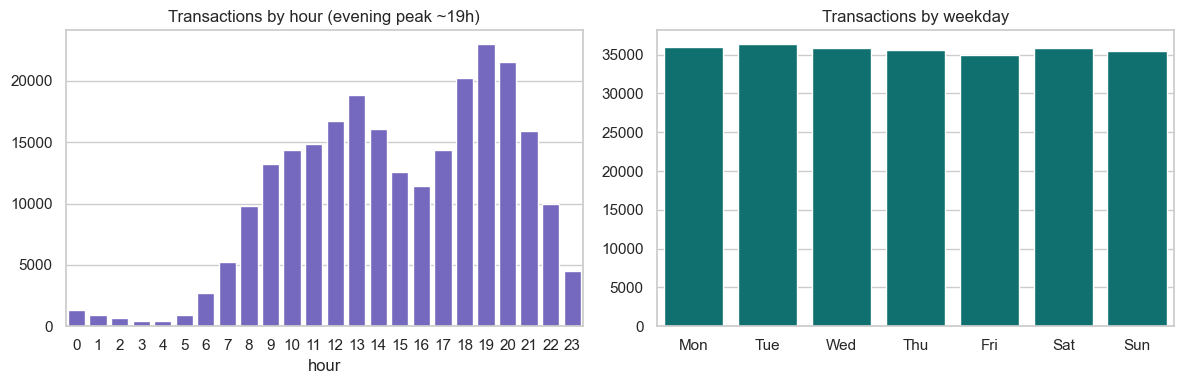

In [10]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
hourly = txn.groupby('txn_hour').size()
sns.barplot(x=hourly.index, y=hourly.values, ax=ax[0], color='slateblue')
ax[0].set_title('Transactions by hour (evening peak ~19h)'); ax[0].set_xlabel('hour')
wdays = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = txn.groupby('txn_day_name').size().reindex(wdays)
sns.barplot(x=[d[:3] for d in wdays], y=dow.values, ax=ax[1], color='teal')
ax[1].set_title('Transactions by weekday')
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / 'p4_time_patterns.png', dpi=110)
plt.show()


## 7. Category & merchant performance

,revenue,gpv,txns,sr
merchant_category,,,,
Electronics,"568,046.00","47,337,130.00",10458,83.00
Travel,"544,858.00","34,053,619.00",8677,84.00
E-commerce,"432,863.00","28,857,553.00",22469,87.00
Fuel,"428,162.00","85,632,540.00",52565,86.00
Food Delivery,"299,583.00","14,979,123.00",36256,88.00
Fashion & Apparel,"297,681.00","16,537,860.00",16367,87.00
Education,"259,917.00","32,489,557.00",5700,83.00
Pharmacy,"138,925.00","13,892,525.00",23447,88.00
Entertainment,"110,834.00","4,433,361.00",8009,88.00


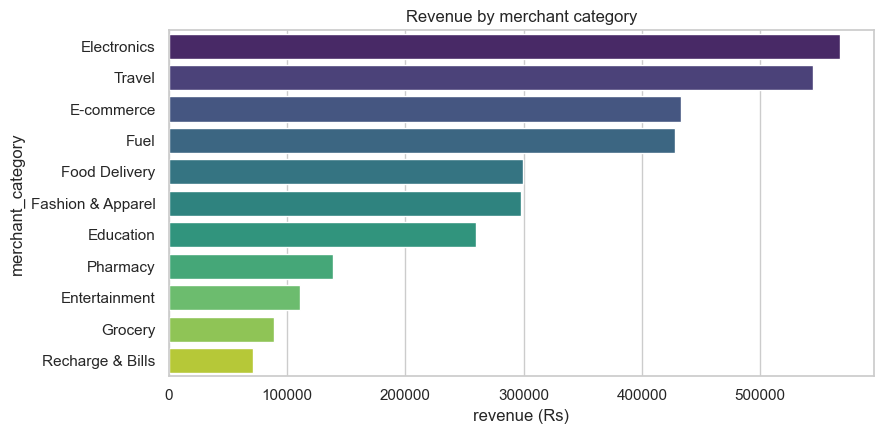

In [11]:

cat = (txn.groupby('merchant_category')
          .agg(revenue=('revenue', 'sum'), gpv=('success_amount', 'sum'),
               txns=('transaction_id', 'size'), sr=('is_success', 'mean'))
          .sort_values('revenue', ascending=False))
display(cat.assign(sr=(cat.sr * 100).round(1)).round(0))
sns.barplot(y=cat.index, x=cat.revenue, palette='viridis')
plt.title('Revenue by merchant category'); plt.xlabel('revenue (Rs)')
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / 'p4_category_revenue.png', dpi=110)
plt.show()


## 8. Regional analysis

,gpv,sr,customers
customer_state,,,
Maharashtra,"57,756,969.00",86.00,1205
Karnataka,"43,542,960.00",87.00,970
Tamil Nadu,"33,314,805.00",87.00,781
Delhi,"30,613,238.00",87.00,726
Uttar Pradesh,"30,427,163.00",87.00,915
Gujarat,"25,927,927.00",87.00,631
Telangana,"24,050,626.00",87.00,649
West Bengal,"18,539,834.00",87.00,546
Kerala,"13,780,277.00",87.00,371


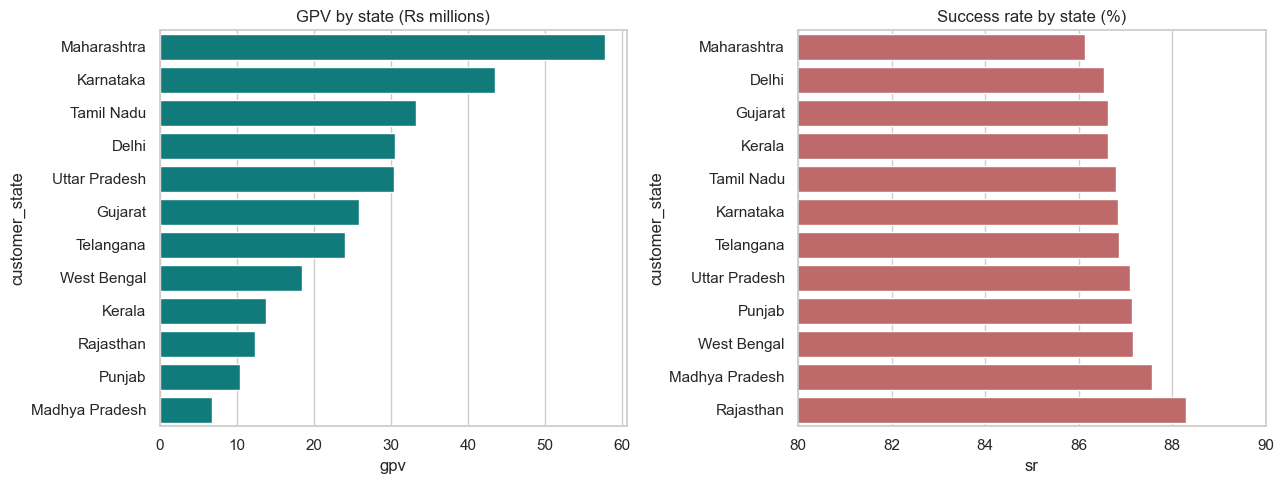

In [12]:

state = (txn.groupby('customer_state')
            .agg(gpv=('success_amount', 'sum'), sr=('is_success', 'mean'),
                 customers=('customer_id', 'nunique'))
            .sort_values('gpv', ascending=False))
display(state.assign(sr=(state.sr * 100).round(2)).round(0))
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(y=state.index, x=state.gpv / 1e6, ax=ax[0], color='darkcyan')
ax[0].set_title('GPV by state (Rs millions)')
srs = state.sort_values('sr')
sns.barplot(y=srs.index, x=srs.sr * 100, ax=ax[1], color='indianred')
ax[1].set_title('Success rate by state (%)'); ax[1].set_xlim(80, 90)
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / 'p4_regional.png', dpi=110)
plt.show()


## 9. Failure trends

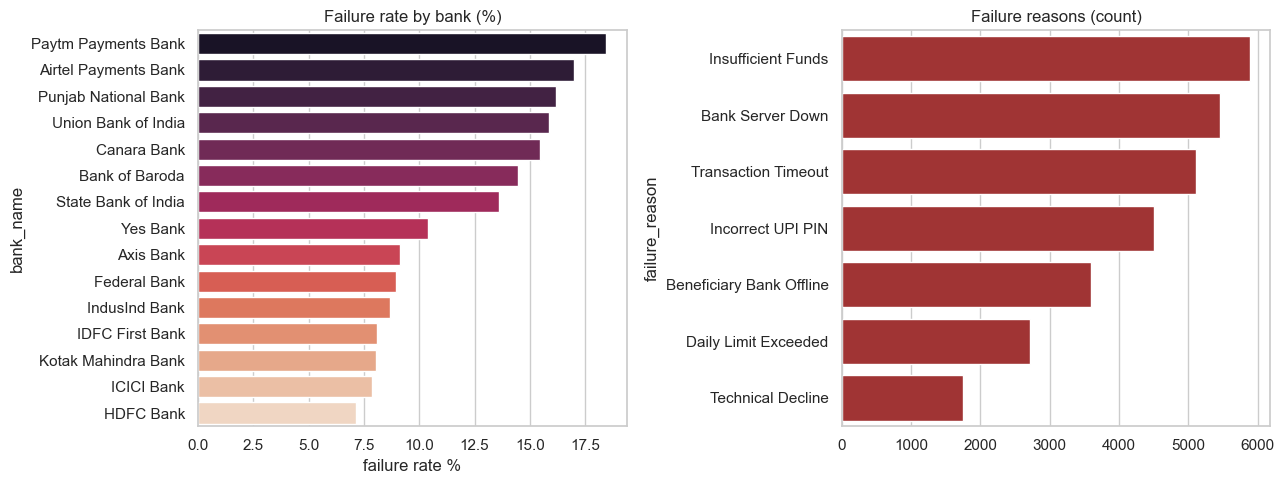

In [13]:

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
bank = (txn.groupby('bank_name').agg(fr=('is_failed', 'mean'))
           .sort_values('fr', ascending=False))
sns.barplot(y=bank.index, x=bank.fr * 100, ax=ax[0], palette='rocket')
ax[0].set_title('Failure rate by bank (%)'); ax[0].set_xlabel('failure rate %')
reasons = txn[txn.is_failed == 1]['failure_reason'].value_counts()
sns.barplot(y=reasons.index, x=reasons.values, ax=ax[1], color='firebrick')
ax[1].set_title('Failure reasons (count)')
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / 'p4_failures.png', dpi=110)
plt.show()


## 10. Feature correlations & persist processed tables

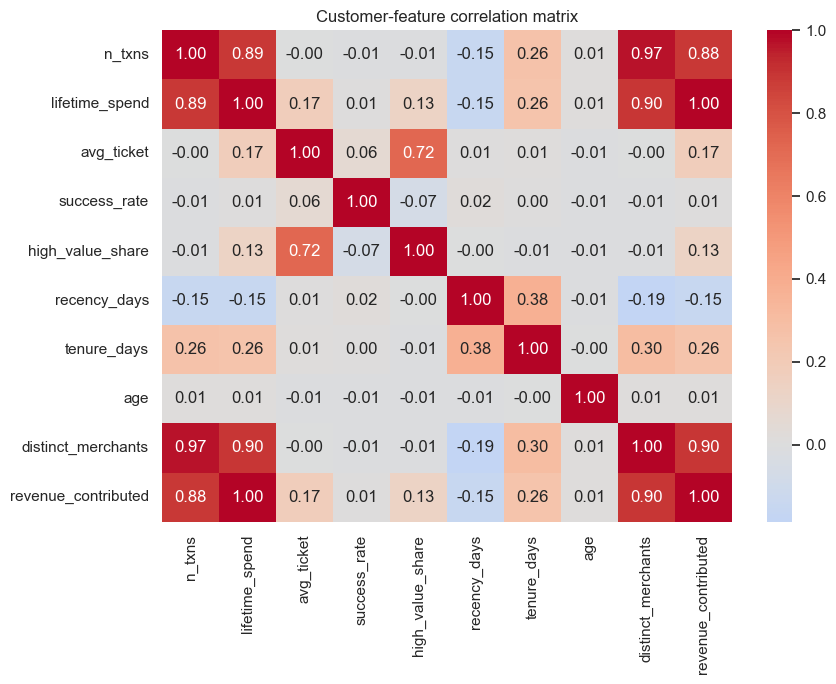

saved customer_features.csv (7747, 21)


In [14]:

num = cust[['n_txns','lifetime_spend','avg_ticket','success_rate','high_value_share',
            'recency_days','tenure_days','age','distinct_merchants','revenue_contributed']]
plt.figure(figsize=(9, 7))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Customer-feature correlation matrix')
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / 'p4_feature_corr.png', dpi=110)
plt.show()

cfg.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
cust.to_csv(cfg.PROCESSED_DIR / 'customer_features.csv', index=False)
print('saved customer_features.csv', cust.shape)


## Phase 4 takeaways

- **Data quality:** the source passes every audit check; the cleaning toolkit is
  demonstrated on an injected-defect sample.
- **Amounts** are right-skewed but log-normal — log transforms are appropriate for
  modelling and parametric tests (used in Phase 5).
- **Growth** compounds strongly month-over-month; usage peaks in the evening.
- **Revenue** concentrates in high-ticket categories (Electronics, Travel,
  E-commerce) and in Maharashtra / Karnataka / Delhi.
- **Failures** are dominated by Payments banks and by "Insufficient Funds" /
  "Bank Server Down" reasons.
- Engineered **transaction** and **customer** feature tables are written to
  `data/processed/` for Phase 5 and Power BI.
